# p03 — Extraction AMOD, tableau croisé ADJ×NOUN, distance et t-SNE 2D
Notebook pipeline reproductible à partir de `data/results_reviews_select_sample_annotations.csv`.

## Imports + constantes + paramètres

In [ ]:
import importlib.util
import subprocess
import sys
import time
from pathlib import Path


def ensure_package(import_name: str, package_name: str = None):
    package_name = package_name or import_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installation de {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])


ensure_package("numpy")
ensure_package("pandas")
ensure_package("sklearn", "scikit-learn")
ensure_package("tqdm")
ensure_package("matplotlib")

import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances

POWER_WATTS = 150
FR_GRID_KGCO2_PER_KWH = 0.056
SCRIPT_START = time.perf_counter()

INPUT_CSV = Path('data/results_reviews_select_sample_annotations.csv')
SAMPLE_SIZE = "total"  # int > 0 ou 'total'
DISTANCE_METRIC = 'cosine'  # cosine | euclidean | manhattan
TOP_ADJECTIVES = 0  # 0 = pas de limite
RANDOM_STATE = 42

OUTPUT_PAIRS = Path('data/results_amod_pairs_per_review.csv')
OUTPUT_CROSSTAB = Path('data/results_amod_crosstab_summary.csv')
OUTPUT_DISTANCE = Path('data/results_amod_distance_summary.csv')
OUTPUT_TSNE = Path('data/results_amod_tsne_summary.csv')
OUTPUT_PAIRS.parent.mkdir(parents=True, exist_ok=True)

print(f'INPUT_CSV: {INPUT_CSV}')
print(f'SAMPLE_SIZE: {SAMPLE_SIZE}')
print(f'DISTANCE_METRIC: {DISTANCE_METRIC}')

INPUT_CSV: data\results_reviews_select_sample_annotations.csv
SAMPLE_SIZE: 20
DISTANCE_METRIC: cosine


## GPU Detection & Parallelization

Optionnel : accélération GPU pour distances et t-SNE via CuPy. CPU automatique en fallback si GPU indisponible.

In [1]:
import torch
import multiprocessing as mp

# Détection GPU
GPU_COUNT = torch.cuda.device_count() if torch.cuda.is_available() else 0
USE_GPU = GPU_COUNT > 0

if USE_GPU:
    print(f"✓ GPU détecté: {GPU_COUNT} device(s)")
    GPU_DEVICE = 0
    torch.cuda.set_device(GPU_DEVICE)
    try:
        ensure_package("cupy")
        import cupy as cp
        CUPY_AVAILABLE = True
        print(f"  ✓ CuPy disponible (GPU {GPU_DEVICE})")
    except Exception as e:
        CUPY_AVAILABLE = False
        print(f"  ✗ CuPy non disponible: {e}")
else:
    print("✗ GPU non détecté → CPU uniquement")
    CUPY_AVAILABLE = False

# Configuration multiprocessing pour éviter deadlocks CUDA
if hasattr(mp, 'set_start_method'):
    try:
        mp.set_start_method('spawn', force=True)
    except RuntimeError:
        pass

✗ GPU non détecté → CPU uniquement


## 2) Helpers techniques + métier

In [2]:
try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(iterable=None, total=None, desc=None, leave=True):
        return iterable

def parse_sample_size(value):
    if isinstance(value, str) and value.lower() == 'total':
        return 'total'
    parsed = int(value)
    if parsed <= 0:
        raise ValueError("SAMPLE_SIZE doit être un entier > 0 ou 'total'")
    return parsed

def normalize_token_text(frame: pd.DataFrame) -> pd.Series:
    lemma = frame['lemma'].astype(str) if 'lemma' in frame.columns else pd.Series('', index=frame.index)
    form = frame['form'].astype(str) if 'form' in frame.columns else pd.Series('', index=frame.index)

    lemma_clean = lemma.where(~lemma.isin(['_', '', 'nan', 'None']), '')
    form_clean = form.where(~form.isin(['_', '', 'nan', 'None']), '')

    token_text = lemma_clean.where(lemma_clean != '', form_clean)
    return token_text.str.strip().str.lower()

def build_group_columns(frame: pd.DataFrame):
    candidates = ['id', 'review_index', 'lang', 'sent_id']
    group_cols = [column for column in candidates if column in frame.columns]
    if 'sent_id' not in group_cols:
        raise ValueError("La colonne 'sent_id' est requise dans le CSV d'annotations")
    return group_cols

def sample_dataframe(frame: pd.DataFrame, sample_size):
    if sample_size == 'total':
        return frame.copy(), 'total'

    if 'id' in frame.columns:
        selected_ids = frame['id'].drop_duplicates().head(sample_size)
        sampled = frame[frame['id'].isin(selected_ids)].copy()
        return sampled, str(sample_size)

    if 'review_index' in frame.columns:
        selected_idx = frame['review_index'].drop_duplicates().head(sample_size)
        sampled = frame[frame['review_index'].isin(selected_idx)].copy()
        return sampled, str(sample_size)

    sampled = frame.head(sample_size).copy()
    return sampled, str(sample_size)

def extract_amod_pairs(frame: pd.DataFrame, group_cols):
    rows = []
    grouped = frame.groupby(group_cols, sort=False)
    iterator = tqdm(grouped, total=grouped.ngroups, desc='Extraction AMOD', leave=False)

    for sent_key, sent_df in iterator:
        if not isinstance(sent_key, tuple):
            sent_key = (sent_key,)

        sent_meta = dict(zip(group_cols, sent_key))

        nouns = sent_df[sent_df['upos'].astype(str).str.upper() == 'NOUN'][['token_id', 'token_text']].copy()
        if nouns.empty:
            continue

        noun_map = nouns.drop_duplicates(subset=['token_id']).set_index('token_id')['token_text'].to_dict()

        amods = sent_df[(sent_df['deprel'].astype(str).str.lower() == 'amod') & (sent_df['upos'].astype(str).str.upper() == 'ADJ')]
        if amods.empty:
            continue

        for _, adj in amods.iterrows():
            try:
                head_id = int(adj['head'])
            except Exception:
                continue

            noun_text = noun_map.get(head_id)
            if not noun_text:
                continue

            adjective_text = str(adj['token_text']).strip().lower()
            if not adjective_text:
                continue

            rows.append({
                **sent_meta,
                'adjective': adjective_text,
                'noun': noun_text,
                'adj_token_id': adj.get('token_id', np.nan),
                'noun_token_id': head_id,
            })

    return pd.DataFrame(rows)

def compute_pairwise_distances_gpu(data, metric='cosine'):
    """Calcul distances GPU-accelerated (CuPy) ou CPU fallback."""
    if CUPY_AVAILABLE:
        try:
            cp_data = cp.asarray(data, dtype=cp.float32)
            if metric == 'cosine':
                # CuPy optimisé pour cosine distance
                norms = cp.linalg.norm(cp_data, axis=1, keepdims=True)
                normalized = cp_data / (norms + 1e-10)
                distances = 1.0 - cp.dot(normalized, normalized.T)
            else:
                # Fallback pour autres métriques
                from scipy.spatial.distance import pdist, squareform
                distances = squareform(pdist(data, metric=metric))
                distances = cp.asarray(distances, dtype=cp.float32)
            return cp.asnumpy(distances).astype(np.float64)
        except Exception as e:
            print(f"⚠ Erreur GPU distances: {e} → CPU")
            return pairwise_distances(data, metric=metric)
    else:
        return pairwise_distances(data, metric=metric)

def compute_tsne(distance_matrix: np.ndarray, random_state: int):
    n_items = distance_matrix.shape[0]

    if n_items == 1:
        return np.array([[0.0, 0.0]])
    if n_items == 2:
        return np.array([[0.0, 0.0], [1.0, 0.0]])

    perplexity = min(30.0, max(2.0, float(n_items - 1) / 3.0))

    model = TSNE(
        n_components=2,
        metric='precomputed',
        init='random',
        learning_rate='auto',
        random_state=random_state,
        perplexity=perplexity,
    )
    return model.fit_transform(distance_matrix)

NameError: name 'pd' is not defined

## 3) Préparation échantillon

In [5]:
if not INPUT_CSV.exists():
    raise FileNotFoundError(f'Fichier introuvable: {INPUT_CSV}')

df = pd.read_csv(INPUT_CSV)
required_columns = {'sent_id', 'token_id', 'head', 'upos', 'deprel'}
missing = sorted(required_columns.difference(df.columns))
if missing:
    raise ValueError(f"Colonnes manquantes dans le CSV d'entrée: {missing}")

df['token_text'] = normalize_token_text(df)
df = df[df['token_text'].notna() & (df['token_text'].astype(str).str.strip() != '')].copy()

sample_param = parse_sample_size(SAMPLE_SIZE)
df_sample, sample_label = sample_dataframe(df, sample_param)
group_cols = build_group_columns(df_sample)

print(f"Lignes d'annotations disponibles: {len(df)}")
print(f'Sample_Size={sample_label} -> lignes traitées: {len(df_sample)}')
df_sample.head()

Lignes d'annotations disponibles: 575713
Sample_Size=20 -> lignes traitées: 935


,id,review_index,lang,sent_id,sent_text,token_id,form,lemma,upos,xpos,feats,head,deprel,deps,misc,token_text
0,916489788146905600,0,it,1,"Alloggio confortevole e pratico, dotato di tut...",1,Alloggio,Alloggio,VERB,V,_,0,ROOT,_,_,alloggio
1,916489788146905600,0,it,1,"Alloggio confortevole e pratico, dotato di tut...",2,confortevole,confortevole,ADJ,A,_,1,amod,_,_,confortevole
2,916489788146905600,0,it,1,"Alloggio confortevole e pratico, dotato di tut...",3,e,e,CCONJ,CC,_,4,cc,_,_,e
3,916489788146905600,0,it,1,"Alloggio confortevole e pratico, dotato di tut...",4,pratico,pratico,ADJ,A,_,2,conj,_,_,pratico
4,916489788146905600,0,it,1,"Alloggio confortevole e pratico, dotato di tut...",5,",",",",PUNCT,FF,_,1,punct,_,_,","


## 4) Boucle principale d’extraction AMOD

In [6]:
pairs_df = extract_amod_pairs(df_sample, group_cols)
print(f'Nombre de paires AMOD extraites: {len(pairs_df)}')
pairs_df.head()

Nombre de paires AMOD extraites: 63


,id,review_index,lang,sent_id,adjective,noun,adj_token_id,noun_token_id
0,921600086982789632,1,fr,3,bon,emplacement,2,3
1,921600086982789632,1,fr,4,typique,appartement,4,3
2,921600086982789632,1,fr,4,bel,vie,9,10
3,926663219961790080,2,en,7,wonderful,gem,3,4
4,926663219961790080,2,en,8,great,location,1,2


## 5) Agrégation: tableau croisé + matrice de distance + t-SNE

In [ ]:
if pairs_df.empty:
    crosstab = pd.DataFrame()
    distance_df = pd.DataFrame()
    tsne_df = pd.DataFrame(columns=['adjective', 'tsne_x', 'tsne_y', 'frequency', 'unique_nouns'])
else:
    crosstab = pd.crosstab(pairs_df['adjective'], pairs_df['noun']).astype(float)

    if TOP_ADJECTIVES and TOP_ADJECTIVES > 0:
        top_adj = crosstab.sum(axis=1).sort_values(ascending=False).head(TOP_ADJECTIVES).index
        crosstab = crosstab.loc[top_adj]

    # Utiliser GPU si disponible
    if USE_GPU:
        print(f"Calcul distances sur GPU (device={GPU_DEVICE}, metric={DISTANCE_METRIC})...")
    distance_matrix = compute_pairwise_distances_gpu(crosstab.values, metric=DISTANCE_METRIC)
    distance_df = pd.DataFrame(distance_matrix, index=crosstab.index, columns=crosstab.index)

    tsne_coords = compute_tsne(distance_matrix, random_state=RANDOM_STATE)
    tsne_df = pd.DataFrame({
        'adjective': crosstab.index,
        'tsne_x': tsne_coords[:, 0],
        'tsne_y': tsne_coords[:, 1],
        'frequency': crosstab.sum(axis=1).values.astype(int),
        'unique_nouns': (crosstab > 0).sum(axis=1).values.astype(int),
    })

print(f"Adjectifs uniques: {0 if crosstab.empty else crosstab.shape[0]}")
print(f"Noms uniques: {0 if crosstab.empty else crosstab.shape[1]}")
print(f"Mode: {'GPU' if USE_GPU else 'CPU'}")
crosstab.head()

Adjectifs uniques: 48
Noms uniques: 42


noun,acesso,amenity,anfitrião,anfitrión,apartment,appartement,area,banheiro,barrio,bathroom,...,restaurante,sight,stay,store,suggestion,ubicación,vie,weekend,welcome,zona
adjective,,,,,,,,,,,,,,,,,,,,,
additional,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
algúno,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
awesome,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
bel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
bon,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 6) Exports CSV

In [8]:
pairs_df.to_csv(OUTPUT_PAIRS, index=False, encoding='utf-8')
crosstab.to_csv(OUTPUT_CROSSTAB, encoding='utf-8')
distance_df.to_csv(OUTPUT_DISTANCE, encoding='utf-8')
tsne_df.to_csv(OUTPUT_TSNE, index=False, encoding='utf-8')

print('Exports terminés:')
print(f'- Paires AMOD: {OUTPUT_PAIRS}')
print(f'- Tableau croisé ADJ x NOUN: {OUTPUT_CROSSTAB}')
print(f'- Matrice de distance ({DISTANCE_METRIC}): {OUTPUT_DISTANCE}')
print(f'- Projection t-SNE 2D: {OUTPUT_TSNE}')

Exports terminés:
- Paires AMOD: data\results_amod_pairs_per_review.csv
- Tableau croisé ADJ x NOUN: data\results_amod_crosstab_summary.csv
- Matrice de distance (cosine): data\results_amod_distance_summary.csv
- Projection t-SNE 2D: data\results_amod_tsne_summary.csv


## 7) Résumé final (runtime / énergie / eCO2)

In [ ]:
elapsed_sec = time.perf_counter() - SCRIPT_START
energy_kwh = (POWER_WATTS / 1000.0) * (elapsed_sec / 3600.0)
energy_wh = energy_kwh * 1000.0
co2_g = energy_kwh * FR_GRID_KGCO2_PER_KWH * 1000.0

print('Résumé:')
print(f'- Nombre de paires AMOD: {len(pairs_df)}')
print(f"- Adjectifs uniques: {0 if crosstab.empty else crosstab.shape[0]}")
print(f"- Noms uniques: {0 if crosstab.empty else crosstab.shape[1]}")
print(f"- Mode calcul: {'GPU' if USE_GPU else 'CPU'}")
if USE_GPU:
    print(f"  Device: CUDA:{GPU_DEVICE} | CuPy: {'✓' if CUPY_AVAILABLE else '✗'}")
print('')
print('Bilan temps/carbone:')
print(f'Temps total: {elapsed_sec:.2f} s')
print(f'Énergie estimée: {energy_wh:.2f} Wh')
print(f'CO2 estimé: {co2_g:.2f} gCO2e')

Résumé:
- Nombre de paires AMOD: 63
- Adjectifs uniques: 48
- Noms uniques: 42

Bilan temps/carbone:
Temps total: 3.33 s
Énergie estimée: 0.14 Wh
CO2 estimé: 0.01 gCO2e


## 8) Visualisation t-SNE 2D (scatter intégré)

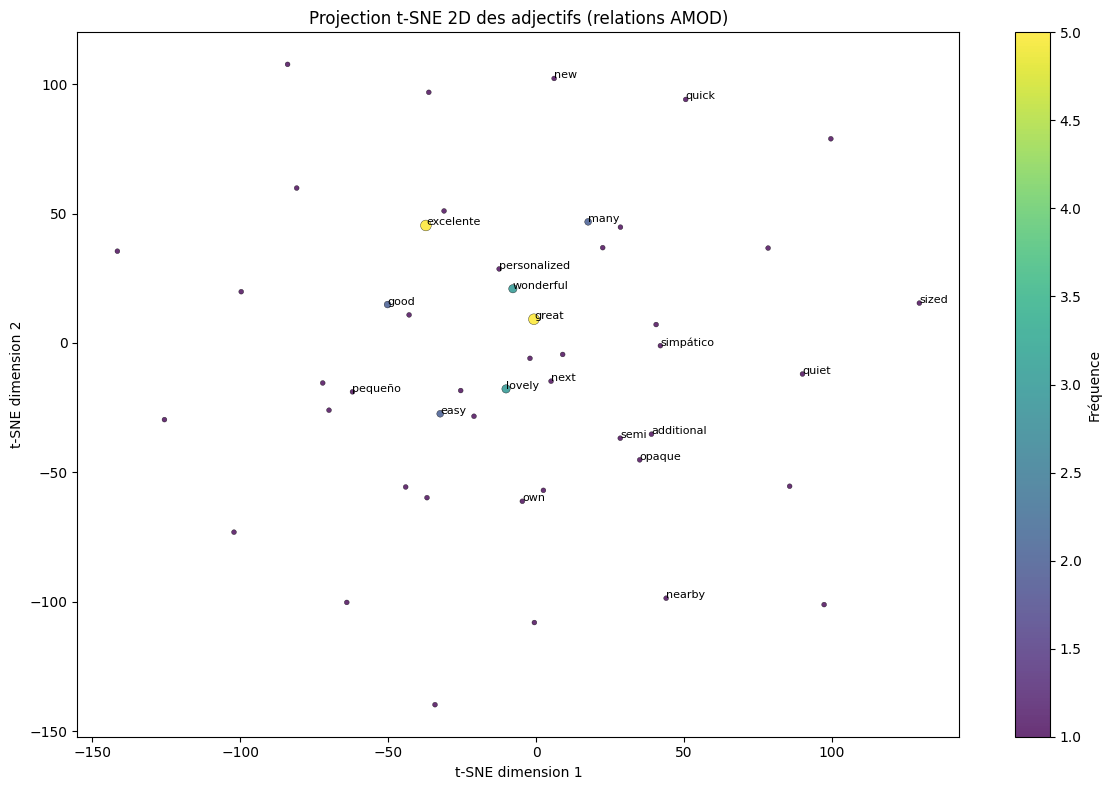

In [10]:
import matplotlib.pyplot as plt

if tsne_df.empty:
    print("Aucune donnée t-SNE à afficher.")
else:
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(
        tsne_df['tsne_x'],
        tsne_df['tsne_y'],
        s=tsne_df['frequency'].clip(lower=1) * 12,
        c=tsne_df['frequency'],
        cmap='viridis',
        alpha=0.8,
        edgecolors='black',
        linewidths=0.3,
    )

    annotate_top = 20
    top_points = tsne_df.sort_values('frequency', ascending=False).head(annotate_top)
    for _, row in top_points.iterrows():
        plt.text(row['tsne_x'], row['tsne_y'], str(row['adjective']), fontsize=8)

    plt.title('Projection t-SNE 2D des adjectifs (relations AMOD)')
    plt.xlabel('t-SNE dimension 1')
    plt.ylabel('t-SNE dimension 2')
    plt.colorbar(scatter, label='Fréquence')
    plt.tight_layout()
    plt.show()